In [35]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import requests
from scipy.stats import pearsonr, spearmanr
from io import StringIO, BytesIO
import zipfile


# ── Paramètres globaux ─────────────────────────────────────────────────────────
# dpi=120 : résolution des figures (120 points par pouce, plus net que le défaut)
plt.rcParams["figure.dpi"] = 120
# whitegrid : fond blanc avec grille légère ; palette "muted" : couleurs douces
sns.set_theme(style="whitegrid", palette="muted")

# URL du fond de carte GeoJSON 
# contours des 96 départements métropolitains
# 
GEOJSON_URL = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"

In [36]:
!pip install great_tables

Import de la base de données avec les déplacements domicile - travail sur le site data gouv 
https://www.data.gouv.fr/datasets/deplacements-domicile-travail

In [37]:

url = "https://www.data.gouv.fr/api/1/datasets/r/b35881a9-da09-49bf-a80e-8fa17651e927"

try:
    # 1. On télécharge le ZIP
    response = requests.get(url)
    
    # 2. On ouvre l'archive en mémoire
    with zipfile.ZipFile(BytesIO(response.content)) as z:
        # 3. On ouvre spécifiquement le fichier de données
        with z.open('DS_RP_NAVETTES_PRINC_2022_data.csv') as f:
            df_transport = pd.read_csv(f, sep=';', encoding='latin-1', low_memory=False)
            
    print(f"✅ Importation réussie ! {len(df_transport)} lignes chargées.")
    print(df_transport.head())

except Exception as e:
    print(f"❌ Erreur : {e}")

✅ Importation réussie ! 1191432 lignes chargées.
      AGE  EMPSTA_ENQ FREQ        GEO GEO_OBJECT RP_MEASURE TRANS WORK_AREA  \
0  Y_GE15           1    A          F     FRANCE        POP     2        _T   
1  Y_GE15           1    A  249710047       EPCI        POP    _T        10   
2  Y_GE15           1    A  249710047       EPCI        POP     6        _T   
3  Y_GE15           1    A          F     FRANCE        POP     1        _T   
4  Y_GE15           1    A         FM     FRANCE        POP    _T        23   

   TIME_PERIOD     OBS_VALUE  
0         2022  1.729514e+06  
1         2022  2.045000e+03  
2         2022  1.310000e+02  
3         2016  1.153684e+06  
4         2011  9.959466e+05  


Vérifications et prise en main de la base 

In [38]:
print(df_transport.info())
print(df_transport.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191432 entries, 0 to 1191431
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   AGE          1191432 non-null  object 
 1   EMPSTA_ENQ   1191432 non-null  int64  
 2   FREQ         1191432 non-null  object 
 3   GEO          1191432 non-null  object 
 4   GEO_OBJECT   1191432 non-null  object 
 5   RP_MEASURE   1191432 non-null  object 
 6   TRANS        1191432 non-null  object 
 7   WORK_AREA    1191432 non-null  object 
 8   TIME_PERIOD  1191432 non-null  int64  
 9   OBS_VALUE    1191432 non-null  float64
dtypes: float64(1), int64(2), object(7)
memory usage: 90.9+ MB
None
AGE                 1
EMPSTA_ENQ          1
FREQ                1
GEO             37894
GEO_OBJECT         11
RP_MEASURE          1
TRANS               8
WORK_AREA           7
TIME_PERIOD         3
OBS_VALUE      804699
dtype: int64


In [39]:
# 1. Suppression des colonnes inutiles
colonnes_a_supprimer = ['AGE', 'EMPSTA_ENQ', 'FREQ', 'RP_MEASURE']
df_transport = df_transport.drop(columns=colonnes_a_supprimer)

# 2. Renommer TIME_PERIOD en ANNEE
df_transport = df_transport.rename(columns={'TIME_PERIOD': 'ANNEE'})

# 3. Filtrer pour ne garder que les modalités spécifiques de GEO_OBJECT
modalites_a_garder = ['COM', 'DEP', 'FRANCE', 'REG']
df_transport = df_transport[df_transport['GEO_OBJECT'].isin(modalites_a_garder)]

# 4. Vérification
print("Modalités restantes dans GEO_OBJECT :", df_transport['GEO_OBJECT'].unique())
print("Colonnes actuelles :", df_transport.columns.tolist())
print(f"Nombre de lignes restantes : {len(df_transport)}")

Modalités restantes dans GEO_OBJECT : ['FRANCE' 'COM' 'DEP' 'REG']
Colonnes actuelles : ['GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA', 'ANNEE', 'OBS_VALUE']
Nombre de lignes restantes : 975848


In [40]:
print("--- Fréquences pour TRANS ---")
print(df_transport['TRANS'].value_counts(dropna=False))

print("\n--- Fréquences pour WORK_AREA ---")
print(df_transport['WORK_AREA'].value_counts(dropna=False))

print("\n--- Fréquences pour GEO_OBJECT ---")
print(df_transport['GEO_OBJECT'].value_counts(dropna=False))

--- Fréquences pour TRANS ---
TRANS
_T     645702
5       69922
1       68066
2       62486
6       55240
3T4     27779
4       24531
3       22122
Name: count, dtype: int64

--- Fréquences pour WORK_AREA ---
WORK_AREA
_T       435039
20_30    104870
21       104818
10       104620
23        91587
22        91430
24T30     43484
Name: count, dtype: int64

--- Fréquences pour GEO_OBJECT ---
GEO_OBJECT
COM       972067
DEP         3185
REG          532
FRANCE        64
Name: count, dtype: int64


In [41]:
# Liste des colonnes à analyser
colonnes_cibles = ['WORK_AREA', 'ANNEE', 'TRANS']

for col in colonnes_cibles:
    print(f"--- Modalités pour {col} ---")
    # Affiche les valeurs uniques
    print(df_transport[col].unique())
    # Affiche le nombre d'occurrences pour chaque modalité
    # print(df[col].value_counts())
    print("\n")

--- Modalités pour WORK_AREA ---
['_T' '23' '10' '21' '22' '24T30' '20_30']


--- Modalités pour ANNEE ---
[2022 2016 2011]


--- Modalités pour TRANS ---
['2' '1' '_T' '4' '3' '5' '6' '3T4']




analyse des modes de transport 

In [42]:
print(df_transport.columns)
print("Modalités de TRANS :", df_transport['TRANS'].unique())
print("Modalités de ANNEE :", df_transport['ANNEE'].unique())
print("Modalités croisées :", pd.crosstab(df_transport['TRANS'], df_transport['ANNEE']))

Index(['GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA', 'ANNEE', 'OBS_VALUE'], dtype='object')
Modalités de TRANS : ['2' '1' '_T' '4' '3' '5' '6' '3T4']
Modalités de ANNEE : [2022 2016 2011]
Modalités croisées : ANNEE    2011    2016    2022
TRANS                        
1           0   34088   33978
2           0   31408   31078
3           0       0   22122
3T4         0   27779       0
4           0       0   24531
5           0   34961   34961
6           0   27634   27606
_T     213872  215450  216380


In [43]:
# 1. Préparation
df_clean = df_transport.copy()
df_clean = df_clean.rename(columns={'OBS_VALUE': 'VALUE'})
df_clean['VALUE'] = pd.to_numeric(df_clean['VALUE'], errors='coerce')

print(df_clean.head(5))

         GEO GEO_OBJECT TRANS WORK_AREA  ANNEE         VALUE
0          F     FRANCE     2        _T   2022  1.729514e+06
3          F     FRANCE     1        _T   2016  1.153684e+06
4         FM     FRANCE    _T        23   2011  9.959466e+05
5          F     FRANCE    _T        23   2011  9.978880e+05
80004  06066        COM    _T        10   2022  1.319644e+02


In [44]:
# modes de transport par période 

# 1. ANNEE vs WORK_AREA
tab_work_area = pd.crosstab(
    df_transport['ANNEE'], 
    df_transport['WORK_AREA'], 
    dropna=False
)

# 2. ANNEE vs TRANS
tab_trans = pd.crosstab(
    df_transport['ANNEE'], 
    df_transport['TRANS'], 
    dropna=False
)

print("--- Tableau Croisé : Année vs Zone de Travail ---")
print(tab_work_area)

print("\n--- Tableau Croisé : Année vs Mode de Transport ---")
print(tab_trans)

--- Tableau Croisé : Année vs Zone de Travail ---
WORK_AREA     10  20_30     21     22     23  24T30      _T
ANNEE                                                      
2011       34882  34957  34940  28755  31311  14061   34966
2016       34882  34958  34939  31182  29918  14607  190834
2022       34856  34955  34939  31493  30358  14816  209239

--- Tableau Croisé : Année vs Mode de Transport ---
TRANS      1      2      3    3T4      4      5      6      _T
ANNEE                                                         
2011       0      0      0      0      0      0      0  213872
2016   34088  31408      0  27779      0  34961  27634  215450
2022   33978  31078  22122      0  24531  34961  27606  216380


On va utiliser que 2016 et 2022, pour 2011 nous n'avons pas le détail des modes de transport.
De plus, en 2016 les modalités 3 et 4 étaient regroupées

In [45]:
# 1. Filtrer pour ne garder que 2016 et 2022
df_final = df_transport[df_transport['ANNEE'].isin([2016, 2022])].copy()

# 2. Gérer le regroupement 3T4 pour l'année 2022
# On identifie les lignes où TRANS est 3 ou 4, et on les transforme en 3T4
df_final.loc[df_final['TRANS'].isin(['3', '4']), 'TRANS'] = '3T4'

# Après avoir renommé 3 et 4 en 3T4, on agrège les valeurs (OBS_VALUE) 
# pour éviter d'avoir deux lignes "3T4" par zone
df_final = df_final.groupby(['ANNEE', 'GEO', 'GEO_OBJECT', 'TRANS', 'WORK_AREA'], as_index=False)['OBS_VALUE'].sum()

# 3. Créer la variable libellé pour les modes de transport (Dictionnaire de correspondance)
mapping_trans = {
    '1': 'Pas de transport',
    '2': 'Marche à pied',
    '3': 'Vélo',
    '4': 'Deux-roues motorisés',
    '5': 'Voiture, camion ou fourgonnette',
    '6': 'Transport en commun',
    '3T4': 'Deux-roues', # Note : dans certains fichiers 3T4 = Voiture, vérifiez bien vos totaux
    '_T': 'Total'
}

df_final['LIB_TRANS'] = df_final['TRANS'].map(mapping_trans)

# 4. Vérification avec le nouveau tableau croisé
print("--- Vérification du regroupement par ANNEE ---")
print(pd.crosstab(df_final['ANNEE'], df_final['TRANS']))

--- Vérification du regroupement par ANNEE ---
TRANS      1      2    3T4      5      6      _T
ANNEE                                           
2016   34088  31408  27779  34961  27634  215450
2022   33978  31078  28228  34961  27606  216380


In [46]:
# 4. Vérification 
print("--- Vérification du regroupement par ANNEE ---")
print(pd.crosstab(df_final['ANNEE'], df_final['LIB_TRANS']))

--- Vérification du regroupement par ANNEE ---
LIB_TRANS  Deux-roues  Marche à pied  Pas de transport   Total  \
ANNEE                                                            
2016            27779          31408             34088  215450   
2022            28228          31078             33978  216380   

LIB_TRANS  Transport en commun  Voiture, camion ou fourgonnette  
ANNEE                                                            
2016                     27634                            34961  
2022                     27606                            34961  


Faire deux tables, une pour 2016 et une pour 2022 avec des données agrégées pour OBS_VALUE par (croisement) département (filtrer GEO_OBJECT = DEP, puis les codes dpt se trouvent dans GEO) et modes de transport.
Puis calculer pour chaque département la part de chaque mode de transport dans le total.

In [47]:
# Liste des codes dep à supprimer (DOM)
dom_codes = ['971', '972', '973', '974', '976'] 

# Filtrage : on ne garde que les lignes où GEO n'est PAS dans la liste
df_final = df_final[~df_final['GEO'].isin(dom_codes)]

# 1. Filtrage pour ne garder que les Départements (DEP) et les années cibles
df_dep = df_final[(df_final['GEO_OBJECT'] == 'DEP') & 
                  (df_final['ANNEE'].isin([2016, 2022])) &
                  (df_final['TRANS'] != '_T')].copy()

# 2. Création des deux tables (2016 et 2022)
# On agrège OBS_VALUE par Département (GEO) et Mode de transport
tables_par_annee = {}

for annee in [2016, 2022]:
    # Pivot pour avoir les départements en lignes et les modes en colonnes
    pivot = df_dep[df_dep['ANNEE'] == annee].pivot_table(
        index=['GEO'], 
        columns=['TRANS', 'LIB_TRANS'], 
        values='OBS_VALUE', 
        aggfunc='sum',
        fill_value=0
    )
    
    # 3. Calcul de la part de chaque mode de transport (%)
    # On divise chaque cellule par la somme de sa ligne (le total du département)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    tables_par_annee[annee] = pivot_pct.round(2)

# --- AFFICHAGE DES RÉSULTATS ---

print("--- PARTS MODALES PAR DÉPARTEMENT EN 2016 (%) ---")
print(tables_par_annee[2016].head())

print("\n" + "="*50 + "\n")

print("--- PARTS MODALES PAR DÉPARTEMENT EN 2022 (%) ---")
print(tables_par_annee[2022].head())

--- PARTS MODALES PAR DÉPARTEMENT EN 2016 (%) ---
TRANS                    1             2        3T4  \
LIB_TRANS Pas de transport Marche à pied Deux-roues   
GEO                                                   
01                    4.21          4.91       2.65   
02                    5.24          7.00       2.18   
03                    6.93          6.81       2.87   
04                    5.92          8.83       1.99   
05                    6.39         12.11       2.48   

TRANS                                   5                   6  
LIB_TRANS Voiture, camion ou fourgonnette Transport en commun  
GEO                                                            
01                                  81.96                6.26  
02                                  80.29                5.29  
03                                  80.35                3.04  
04                                  80.39                2.86  
05                                  75.22                3.80

In [48]:
# On s'assure de travailler sur les données filtrées pour les départements
df_dep_only = df_final[df_final['GEO_OBJECT'] == 'DEP']

for annee in sorted(df_final['ANNEE'].unique()):
    # Extraction des codes GEO uniques pour l'année en cours
    codes_geo = sorted(df_dep_only[df_dep_only['ANNEE'] == annee]['GEO'].unique())
    
    print(f"\n--- MODALITÉS GEO (DÉPARTEMENTS) EN {annee} ---")
    print(f"Nombre total : {len(codes_geo)}")
    print(codes_geo)


--- MODALITÉS GEO (DÉPARTEMENTS) EN 2016 ---
Nombre total : 96
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95']

--- MODALITÉS GEO (DÉPARTEMENTS) EN 2022 ---
Nombre total : 96
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', 

In [49]:
from fonctions import afficher_gt_part_modale
# --- AFFICHAGE ---

# Affichage pour 2016
print(f"Génération de la table 2016...")
gt_2016 = afficher_gt_part_modale(tables_par_annee[2016], 2016)
display(gt_2016)

# Affichage pour 2022
print(f"Génération de la table 2022...")
gt_2022 = afficher_gt_part_modale(tables_par_annee[2022], 2022)
display(gt_2022)

Génération de la table 2016...


GT(_tbl_data=   Département  Pas de transport  Marche à pied  Deux-roues  \
0           01              4.21           4.91        2.65   
1           02              5.24           7.00        2.18   
2           03              6.93           6.81        2.87   
3           04              5.92           8.83        1.99   
4           05              6.39          12.11        2.48   
..         ...               ...            ...         ...   
91          91              3.05           4.78        2.79   
92          92              3.30           9.68        7.26   
93          93              2.93           6.22        3.73   
94          94              2.85           6.66        4.86   
95          95              2.76           4.91        2.75   

    Voiture, camion ou fourgonnette  Transport en commun  
0                             81.96                 6.26  
1                             80.29                 5.29  
2                             80.35                 3.04  
3                             80.39                 2.86  
4                             75.22                 3.80  
..                              ...                  ...  
91                            61.19                28.19  
92                            32.96                46.80  
93                            36.03                51.09  
94                            38.43                47.19  
95                            53.96                35.62  

[96 rows x 6 columns], _body=<great_tables._gt_data.Body object at 0x7f327acdc8d0>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='left', column_width=None), ColInfo(var='Pas de transport', type=<ColInfoTypeEnum.default: 1>, column_label='Pas de transport', column_align='right', column_width=None), ColInfo(var='Marche à pied', type=<ColInfoTypeEnum.default: 1>, column_label='Marche à pied', column_align='right', column_width=None), ColInfo(var='Deux-roues', type=<ColInfoTypeEnum.default: 1>, column_label='Deux-roues', column_align='right', column_width=None), ColInfo(var='Voiture, camion ou fourgonnette', type=<ColInfoTypeEnum.default: 1>, column_label='Voiture, camion ou fourgonnette', column_align='right', column_width=None), ColInfo(var='Transport en commun', type=<ColInfoTypeEnum.default: 1>, column_label='Transport en commun', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f327f0c1590>, _spanners=Spanners([]), _heading=Heading(title='Parts modales de transport par département en 2016', subtitle='Répartition en % des actifs', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f31ad8f08a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f327dcb6b10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f31ad865f90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f31ad8665d0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_f

Génération de la table 2022...


GT(_tbl_data=   Département  Pas de transport  Marche à pied  Deux-roues  \
0           01              3.81           4.63        3.49   
1           02              4.58           6.23        2.15   
2           03              6.06           6.50        3.25   
3           04              5.51           8.00        2.74   
4           05              6.24          11.83        3.34   
..         ...               ...            ...         ...   
91          91              3.06           4.70        3.25   
92          92              3.47          10.07        9.99   
93          93              2.63           6.17        5.75   
94          94              3.00           6.49        6.72   
95          95              2.73           4.65        3.13   

    Voiture, camion ou fourgonnette  Transport en commun  
0                             81.47                 6.60  
1                             81.87                 5.17  
2                             81.19                 3.00  
3                             80.70                 3.05  
4                             74.93                 3.66  
..                              ...                  ...  
91                            60.81                28.18  
92                            28.71                47.77  
93                            34.57                50.87  
94                            35.54                48.25  
95                            53.12                36.37  

[96 rows x 6 columns], _body=<great_tables._gt_data.Body object at 0x7f327f0e4850>, _boxhead=Boxhead([ColInfo(var='Département', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='left', column_width=None), ColInfo(var='Pas de transport', type=<ColInfoTypeEnum.default: 1>, column_label='Pas de transport', column_align='right', column_width=None), ColInfo(var='Marche à pied', type=<ColInfoTypeEnum.default: 1>, column_label='Marche à pied', column_align='right', column_width=None), ColInfo(var='Deux-roues', type=<ColInfoTypeEnum.default: 1>, column_label='Deux-roues', column_align='right', column_width=None), ColInfo(var='Voiture, camion ou fourgonnette', type=<ColInfoTypeEnum.default: 1>, column_label='Voiture, camion ou fourgonnette', column_align='right', column_width=None), ColInfo(var='Transport en commun', type=<ColInfoTypeEnum.default: 1>, column_label='Transport en commun', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f327dca7820>, _spanners=Spanners([]), _heading=Heading(title='Parts modales de transport par département en 2022', subtitle='Répartition en % des actifs', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f327acdcd10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f327acdd040>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f327dca7490>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f327a9cc2b0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_f

Calcul des évolutions 

In [50]:

# 1. Calcul de la différence (2022 - 2016)
df_evol = tables_par_annee[2022] - tables_par_annee[2016]

print("--- ÉVOLUTION 2016-2022 (en points) ---")
print(df_evol.head())


--- ÉVOLUTION 2016-2022 (en points) ---
TRANS                    1             2        3T4  \
LIB_TRANS Pas de transport Marche à pied Deux-roues   
GEO                                                   
01                   -0.40         -0.28       0.84   
02                   -0.66         -0.77      -0.03   
03                   -0.87         -0.31       0.38   
04                   -0.41         -0.83       0.75   
05                   -0.15         -0.28       0.86   

TRANS                                   5                   6  
LIB_TRANS Voiture, camion ou fourgonnette Transport en commun  
GEO                                                            
01                                  -0.49                0.34  
02                                   1.58               -0.12  
03                                   0.84               -0.04  
04                                   0.31                0.19  
05                                  -0.29               -0.14  


Les départements avec les évolutions positives les plus importantes

In [53]:
#from fonctions import extraire_extremes

def extraire_extremes(data, nom_mode):
    if isinstance(data, pd.DataFrame):
        serie = data.iloc[:, 0]
    else:
        serie = data

    # Tri des valeurs (maintenant on est sûr que c'est une Series)
    top_progression = serie.sort_values(ascending=False).head(5)
    top_recul = serie.sort_values(ascending=True).head(5)

    print(f"\n--- {nom_mode.upper()} : Les plus fortes PROGRESSIONS ---")
    print(top_progression.to_string())
    print(f"\n--- {nom_mode.upper()} : Les plus forts RECULS ---")
    print(top_recul.to_string())

# --- AFFICHAGE ---
extraire_extremes(evol_2roues, "Deux-roues")
extraire_extremes(evol_tc, "Transports en commun")


--- DEUX-ROUES : Les plus fortes PROGRESSIONS ---
GEO
75    4.13
69    2.77
92    2.73
44    2.35
33    2.33

--- DEUX-ROUES : Les plus forts RECULS ---
GEO
2A   -0.06
02   -0.03
89    0.03
60    0.05
2B    0.06

--- TRANSPORTS EN COMMUN : Les plus fortes PROGRESSIONS ---
GEO
78    1.86
06    1.56
74    1.53
33    1.08
94    1.06

--- TRANSPORTS EN COMMUN : Les plus forts RECULS ---
GEO
75   -3.27
90   -0.99
70   -0.56
28   -0.51
2A   -0.30


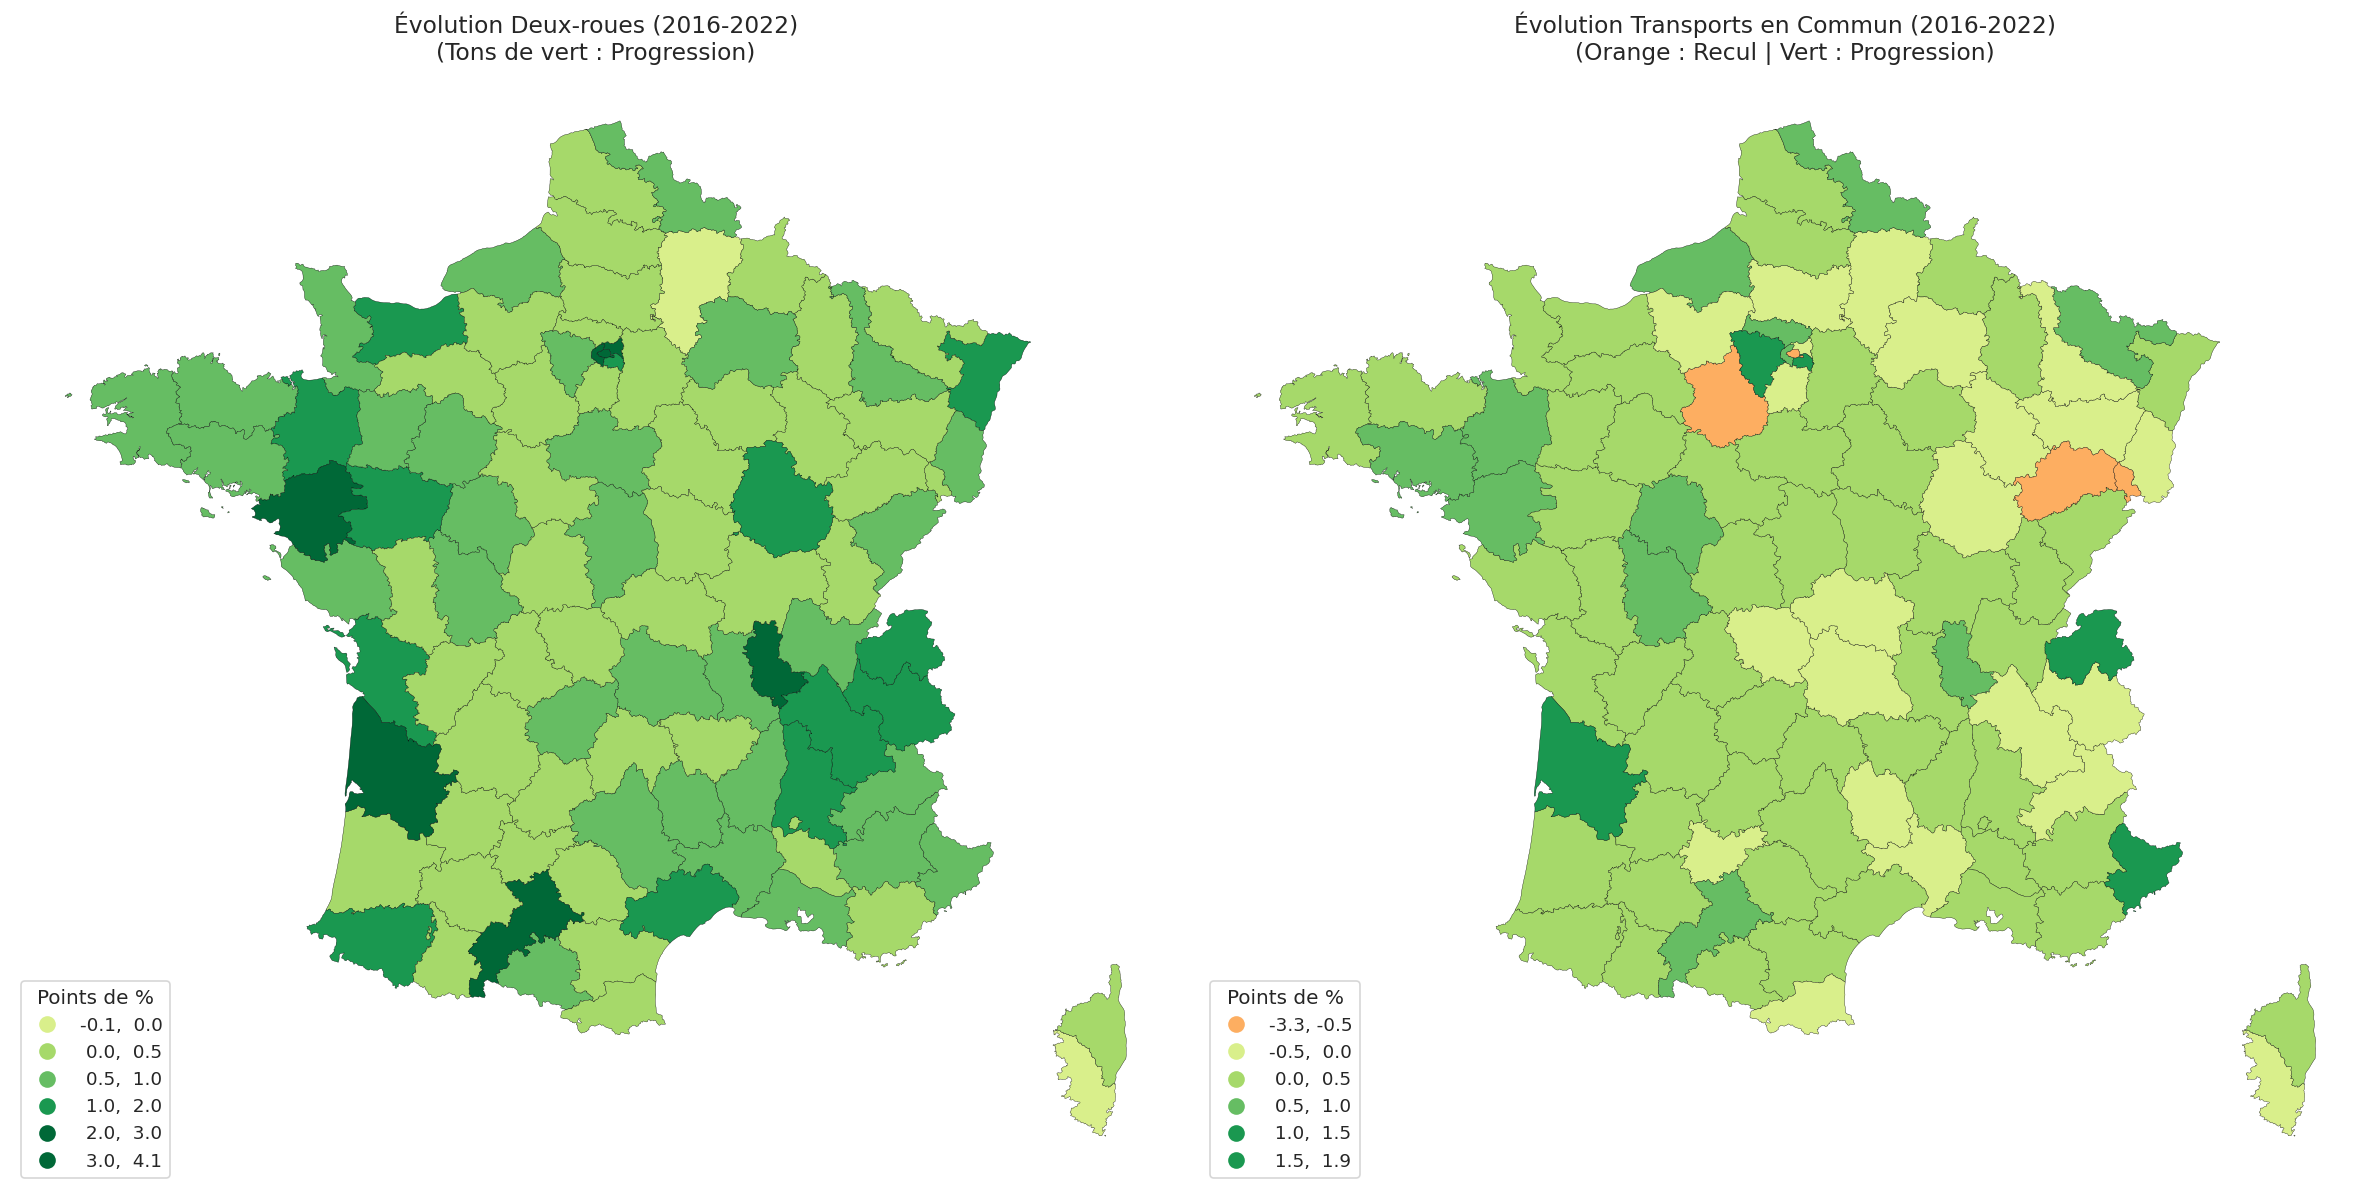

In [55]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Définition des couleurs personnalisées
# Pour 2-roues (5 classes : 0-0.5, 0.5-1, 1-2, 2-3, >3) -> tons de vert
colors_2roues = ['#D9EF8B', '#A6D96A', '#66BD63', '#1A9850', '#006837']
cmap_2roues = ListedColormap(colors_2roues)

# Pour TC (5 classes : -0.5-0 (Orange), 0-0.5, 0.5-1, 1-1.5, >1.5 (Verts))
colors_tc = ['#FDAE61', '#D9EF8B', '#A6D96A', '#66BD63', '#1A9850']
cmap_tc = ListedColormap(colors_tc)

# 4. Affichage des cartes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Carte Deux-roues
map_2roues.plot(
    column=map_2roues.columns[-1], 
    cmap=cmap_2roues, 
    scheme='UserDefined',
    classification_kwds={'bins': bins_2roues},
    legend=True, 
    ax=ax1,
    legend_kwds={
        'title': "Points de %",
        'loc': 'lower left',
        'fmt': "{:.1f}"
    },
    edgecolor='black', linewidth=0.2
)
ax1.set_title("Évolution Deux-roues (2016-2022)\n(Tons de vert : Progression)", fontsize=14)
ax1.axis('off')

# Carte Transports en commun
map_tc.plot(
    column=map_tc.columns[-1], 
    cmap=cmap_tc, 
    scheme='UserDefined',
    classification_kwds={'bins': bins_tc},
    legend=True, 
    ax=ax2,
    legend_kwds={
        'title': "Points de %", 
        'loc': 'lower left',
        'fmt': "{:.1f}"
    },
    edgecolor='black', linewidth=0.2
)
ax2.set_title("Évolution Transports en Commun (2016-2022)\n(Orange : Recul | Vert : Progression)", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()